In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
student = pd.read_csv('student-mat.csv')
df = pd.DataFrame(student)

# df.isnull().sum()
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# ENCODING - LABEL ENCODING

<Axes: >

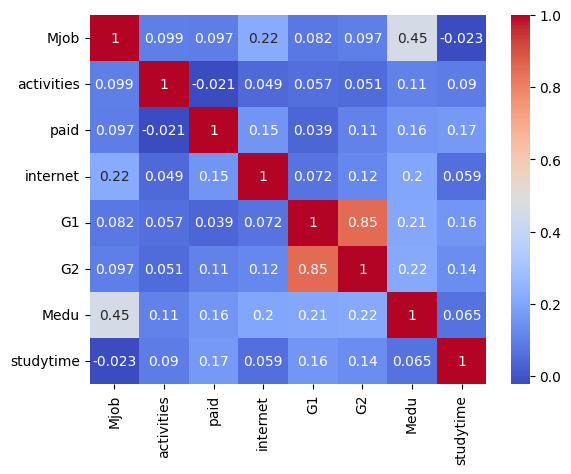

In [25]:
# df['guardian'] = df['guardian'].map({'father':1,'mother':0})
# df['address'] = df['address'].map({'U':1,'T':0})
encoder = LabelEncoder()

df['guardian'] = encoder.fit_transform(df['guardian'])
df['address'] = encoder.fit_transform(df['address'])
df['famsize'] = encoder.fit_transform(df['famsize'])
df['Mjob'] = encoder.fit_transform(df['Mjob'])
df['Fjob'] = encoder.fit_transform(df['Fjob'])
df['paid'] = encoder.fit_transform(df['paid'])
df['activities'] = encoder.fit_transform(df['activities'])
df['internet'] = encoder.fit_transform(df['internet'])
df['higher'] = encoder.fit_transform(df['higher'])


df[['guardian','address','famsize','Mjob','Fjob','paid','activities','internet','higher']].sample(20)


sns.heatmap(data=df[['Mjob','activities','paid','internet','G1','G2','Medu','studytime']].corr(), annot = True, cmap='coolwarm')



In [49]:
# X = df.drop(columns=['G3'])
"""learning:
'Mjob','paid','internet' -> are better for linear regression increases the r2 score by 0.03 but is hardly noticable
'Mjob','paid','internet' -> degrades and reduce the r2 score from 0.87 to 0.82

conclusion: not adding is better for the all models"""

X = df[['G1','G2','Medu','studytime']]
Y = df['G3']
X_train, x_test, Y_train, y_test = train_test_split(X,Y,train_size=0.8, test_size=0.2, random_state=42)

## 1. LINEAR REGRESSION

In [27]:
model = LinearRegression()

model.fit(X_train,Y_train)

lr_pred = model.predict(x_test)




In [28]:
model = DecisionTreeRegressor(max_depth=5)

model.fit(X_train,Y_train)

dt_pred = model.predict(x_test)

In [80]:
rf_X = df[['G1', 'G2', 'Medu', 'studytime', 'failures', 'absences', 'Fedu', 'age']]
rf_Y = df['G3']
X_train_rf, x_test_rf, Y_train_rf, y_test_rf = train_test_split(rf_X,rf_Y,train_size=0.8, test_size=0.2, random_state=0)
model = RandomForestRegressor(max_depth=10,random_state=42,n_estimators=100)
model.fit(X_train_rf,Y_train_rf)

rf_pred = model.predict(x_test_rf)

In [83]:
for name, pred,yt in [('LinearRegression',lr_pred,y_test),('DecisionTreeRegressor',dt_pred,y_test),('RandomForestRegressor',rf_pred,y_test_rf)]:
    print('\n',name)
    print('mean_absolute_value:', mean_absolute_error(yt,pred))
    print('mean_square_error:',mean_squared_error(yt,pred))
    print('r2_score:',r2_score(yt,pred))




 LinearRegression
mean_absolute_value: 1.2609754177825023
mean_square_error: 4.16093996463485
r2_score: 0.7970772800355852

 DecisionTreeRegressor
mean_absolute_value: 1.0659703055106118
mean_square_error: 2.6534612786925234
r2_score: 0.8705947250936139

 RandomForestRegressor
mean_absolute_value: 1.0439002572109133
mean_square_error: 3.216523439885671
r2_score: 0.8834121871721407
